# Research Question

### To what extent are location, floor size, and number of bathrooms associated with the rental prices of two-bedroom properties in Yas Island and Al Reem Island, Abu Dhabi?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

In [2]:
df = pd.read_excel(r"C:\Users\Hp\Desktop\Rental Dataset.xlsx")

### Data Preparation and Cleaning

In [3]:
df.head(5)

,DESCRIPTION,EXTRACT_DATE,DATA_SOURCE,PROPERTY_TYPE,LOCATION,REGION,PRICE,FLOOR_SIZE,NO_OF_BEDROOMS,NO_OF_BATHROOMS,PRICE_SQFT,Unnamed: 11
0,A Lovely Apartment Perfect As Your Next Home,20211028,Dubizzle,Rent,Yas Island,Abu Dhabi,85000,1068,2,2,79.588015,NaN
1,A Resort Style Lifestyle With Water Views,20211028,Dubizzle,Rent,Yas Island,Abu Dhabi,79960,1050,2,2,76.152381,NaN
2,A Splendid Apartment With Multiple Functions,20211028,Dubizzle,Rent,Yas Island,Abu Dhabi,85000,1044,2,2,81.417625,NaN
3,AMAZING 2BD DIRECT FROM LANDLORD,20211028,Dubizzle,Rent,Yas Island,Abu Dhabi,115000,1472,2,3,78.125000,NaN
4,AMAZING VIEW | Book Now! | Flexible Payment,20211028,Dubizzle,Rent,Yas Island,Abu Dhabi,84995,1674,2,3,50.773596,NaN


In [4]:
df = df.drop(columns=["Unnamed: 11"])

In [5]:
df = df.drop(columns=["EXTRACT_DATE"])

In [6]:
df.head(5)

,DESCRIPTION,DATA_SOURCE,PROPERTY_TYPE,LOCATION,REGION,PRICE,FLOOR_SIZE,NO_OF_BEDROOMS,NO_OF_BATHROOMS,PRICE_SQFT
0,A Lovely Apartment Perfect As Your Next Home,Dubizzle,Rent,Yas Island,Abu Dhabi,85000,1068,2,2,79.588015
1,A Resort Style Lifestyle With Water Views,Dubizzle,Rent,Yas Island,Abu Dhabi,79960,1050,2,2,76.152381
2,A Splendid Apartment With Multiple Functions,Dubizzle,Rent,Yas Island,Abu Dhabi,85000,1044,2,2,81.417625
3,AMAZING 2BD DIRECT FROM LANDLORD,Dubizzle,Rent,Yas Island,Abu Dhabi,115000,1472,2,3,78.125000
4,AMAZING VIEW | Book Now! | Flexible Payment,Dubizzle,Rent,Yas Island,Abu Dhabi,84995,1674,2,3,50.773596


In [7]:
df.shape

(358, 10)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DESCRIPTION      358 non-null    str    
 1   DATA_SOURCE      358 non-null    str    
 2   PROPERTY_TYPE    358 non-null    str    
 3   LOCATION         358 non-null    str    
 4   REGION           358 non-null    str    
 5   PRICE            358 non-null    int64  
 6   FLOOR_SIZE       358 non-null    int64  
 7   NO_OF_BEDROOMS   358 non-null    int64  
 8   NO_OF_BATHROOMS  358 non-null    int64  
 9   PRICE_SQFT       358 non-null    float64
dtypes: float64(1), int64(4), str(5)
memory usage: 57.0 KB


In [9]:
categorical_cols = [
    "DATA_SOURCE",
    "PROPERTY_TYPE",
    "LOCATION",
    "REGION"
]

In [10]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


DATA_SOURCE:
<ArrowStringArray>
['Dubizzle']
Length: 1, dtype: str

PROPERTY_TYPE:
<ArrowStringArray>
['Rent']
Length: 1, dtype: str

LOCATION:
<ArrowStringArray>
['Yas Island', 'Al Reem Island']
Length: 2, dtype: str

REGION:
<ArrowStringArray>
['Abu Dhabi']
Length: 1, dtype: str


In [11]:
df.isnull().sum()

DESCRIPTION        0
DATA_SOURCE        0
PROPERTY_TYPE      0
LOCATION           0
REGION             0
PRICE              0
FLOOR_SIZE         0
NO_OF_BEDROOMS     0
NO_OF_BATHROOMS    0
PRICE_SQFT         0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

In [13]:
df.describe()

,PRICE,FLOOR_SIZE,NO_OF_BEDROOMS,NO_OF_BATHROOMS,PRICE_SQFT
count,358.000000,358.000000,358.0,358.000000,358.000000
mean,90035.544693,1320.986034,2.0,2.807263,68.772608
std,18789.327604,226.662874,0.0,0.583866,11.571150
min,62500.000000,678.000000,2.0,1.000000,45.072115
25%,77250.000000,1108.000000,2.0,2.000000,60.084823
50%,85000.000000,1308.000000,2.0,3.000000,66.381818
75%,99999.750000,1500.000000,2.0,3.000000,76.691992
max,184000.000000,2421.000000,2.0,5.000000,111.034004


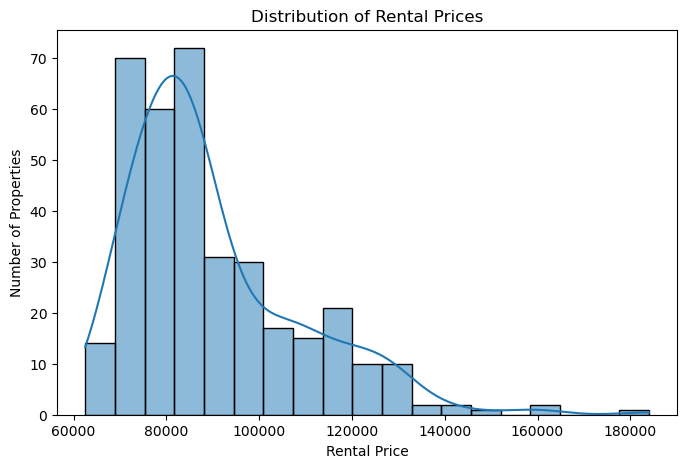

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["PRICE"], kde=True)

plt.title("Distribution of Rental Prices")
plt.xlabel("Rental Price")
plt.ylabel("Number of Properties")

plt.show()

The histogram shows that rental prices are concentrated in the lower-to-middle price range, with a relatively long right tail caused by higher-priced properties.

In [15]:
df["PRICE"].skew()

np.float64(1.3581132521054344)

In [16]:
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers, lower, upper

for col in ['PRICE', 'FLOOR_SIZE', 'NO_OF_BATHROOMS', 'PRICE_SQFT']:
    outliers, low, up = find_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers (bounds: {low:.2f} to {up:.2f})")

PRICE: 8 outliers (bounds: 43125.38 to 134124.38)
FLOOR_SIZE: 1 outliers (bounds: 520.00 to 2088.00)
NO_OF_BATHROOMS: 1 outliers (bounds: 0.50 to 4.50)
PRICE_SQFT: 2 outliers (bounds: 35.17 to 101.60)


In [17]:
def get_outlier_indices(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return set(df[(df[column] < lower) | (df[column] > upper)].index)

price_idx = get_outlier_indices(df, 'PRICE')
floor_idx = get_outlier_indices(df, 'FLOOR_SIZE')
bath_idx = get_outlier_indices(df, 'NO_OF_BATHROOMS')
psf_idx = get_outlier_indices(df, 'PRICE_SQFT')

print("Price ∩ Floor Size:", price_idx & floor_idx)
print("Price ∩ Bathrooms:", price_idx & bath_idx)
print("Price ∩ Price/SqFt:", price_idx & psf_idx)
print("All unique outlier rows combined:", price_idx | floor_idx | bath_idx | psf_idx)

df.loc[list(price_idx | floor_idx | bath_idx | psf_idx)]

Price ∩ Floor Size: {115}
Price ∩ Bathrooms: set()
Price ∩ Price/SqFt: {93, 23}
All unique outlier rows combined: {355, 104, 170, 17, 115, 23, 312, 317, 93}


,DESCRIPTION,DATA_SOURCE,PROPERTY_TYPE,LOCATION,REGION,PRICE,FLOOR_SIZE,NO_OF_BEDROOMS,NO_OF_BATHROOMS,PRICE_SQFT
355,ZERO Commission | With Maids Room,Dubizzle,Rent,Al Reem Island,Abu Dhabi,136000,1858,2,4,73.196986
104,HOTTEST PRICE | Full Sea and Golf Course View,Dubizzle,Rent,Yas Island,Abu Dhabi,160000,1800,2,3,88.888889
170,Luxury apartment| bigger layout | 2 bed room A...,Dubizzle,Rent,Al Reem Island,Abu Dhabi,136000,1450,2,3,93.793103
17,Brand New | Beach Access | Biggest Layout | 2+...,Dubizzle,Rent,Yas Island,Abu Dhabi,140000,1560,2,4,89.743590
115,Single Row | Fully Fitted Kitchen | Well Maint...,Dubizzle,Rent,Yas Island,Abu Dhabi,184000,2421,2,3,76.001652
23,Bright Spacious | Brand New I Community view,Dubizzle,Rent,Yas Island,Abu Dhabi,149500,1456,2,3,102.678571
312,Big Lay out 2 Br Apartment /Ready to Move-in,Dubizzle,Rent,Al Reem Island,Abu Dhabi,110000,1722,2,5,63.879210
317,Floor to Ceiling Windows|Canal View|Ample Terrace,Dubizzle,Rent,Al Reem Island,Abu Dhabi,140000,1501,2,3,93.271153
93,Ready For Occupancy! Maids Room | Balcony | D...,Dubizzle,Rent,Yas Island,Abu Dhabi,160000,1441,2,2,111.034004


Although several observations were identified as statistical outliers using the 1.5×IQR rule, inspection of the corresponding property characteristics suggests that these observations are plausible listings rather than obvious data-entry errors. Therefore, they were retained for the analysis.

## Bivariate Exploratory Analysis 

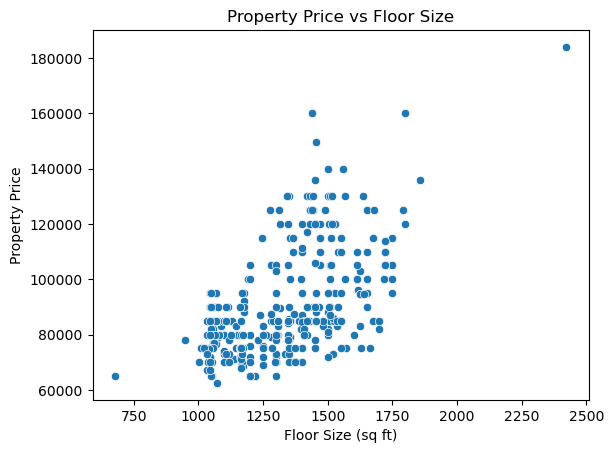

In [18]:
sns.scatterplot(
    data=df,
    x="FLOOR_SIZE",
    y="PRICE"
)

plt.title("Property Price vs Floor Size")
plt.xlabel("Floor Size (sq ft)")
plt.ylabel("Property Price")
plt.show()

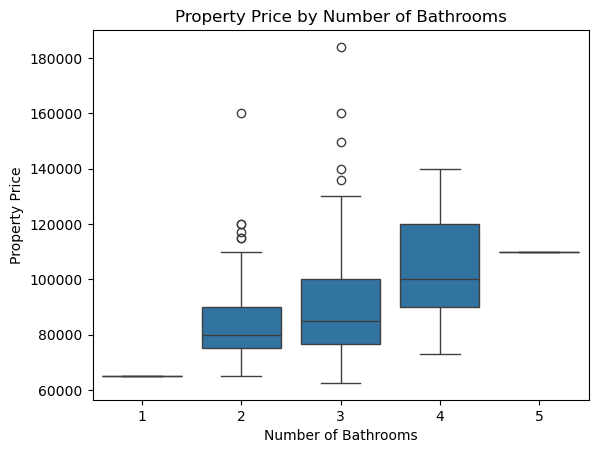

In [19]:
sns.boxplot(
    data=df,
    x="NO_OF_BATHROOMS",
    y="PRICE"
)

plt.title("Property Price by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Property Price")
plt.show()

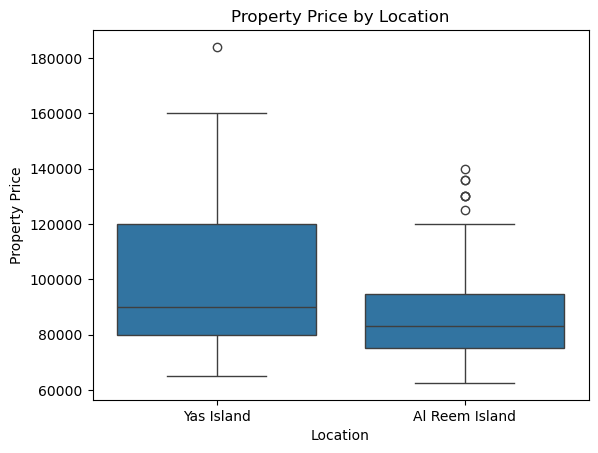

In [20]:
sns.boxplot(
    data=df,
    x="LOCATION",
    y="PRICE"
)

plt.title("Property Price by Location")
plt.xlabel("Location")
plt.ylabel("Property Price")
plt.show()

## Hypothesis Testing 

H₀: Mean property prices are equal between Yas Island and Al Reem Island.

H₁: Mean property prices differ between Yas Island and Al Reem Island.

In [21]:
yas = df[df['LOCATION'] == 'Yas Island']['PRICE']
al_reem = df[df['LOCATION'] == 'Al Reem Island']['PRICE']

t_stat, p_value = st.ttest_ind(yas, al_reem)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.4f}")

T-statistic: 6.584, P-value: 0.0000


Reject H₀. There is strong statistical evidence that the mean property prices differ between the two locations.

### Correlational Analysis

In [22]:
corr_cols = ['PRICE', 'FLOOR_SIZE', 'NO_OF_BATHROOMS']
corr_matrix = df[corr_cols].corr()

print(corr_matrix)

                    PRICE  FLOOR_SIZE  NO_OF_BATHROOMS
PRICE            1.000000    0.587206         0.262800
FLOOR_SIZE       0.587206    1.000000         0.525615
NO_OF_BATHROOMS  0.262800    0.525615         1.000000


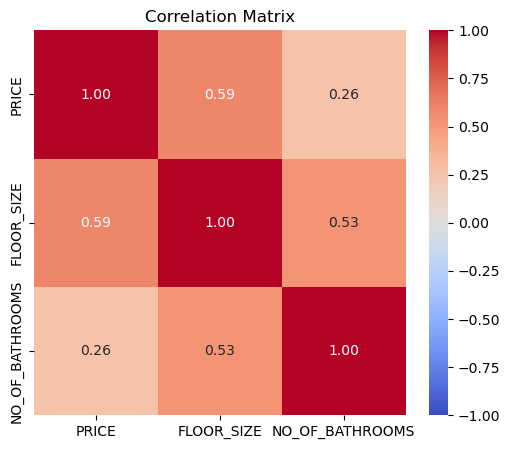

In [23]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

### Regression Analysis 

In [24]:
df['LOCATION_YasIsland'] = (df['LOCATION'] == 'Yas Island').astype(int)

In [26]:
import statsmodels.api as sm

X = df[['LOCATION_YasIsland', 'NO_OF_BATHROOMS', 'FLOOR_SIZE']]
y = df['PRICE']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                     168.1
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           9.37e-68
Time:                        21:32:04   Log-Likelihood:                -3872.0
No. Observations:                 358   AIC:                             7752.
Df Residuals:                     354   BIC:                             7768.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               2483.3555   4384

The model explains 58.8% of the variation in property prices. Location and floor size show statistically significant positive associations with price, while the number of bathrooms has a positive but statistically non-significant association at the 5% level. 

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


             Variable       VIF
0               const  1.000000
1  LOCATION_YasIsland  1.127091
2     NO_OF_BATHROOMS  1.463415
3          FLOOR_SIZE  1.393944


The VIF values ranged from 1.13 to 1.46, indicating no evidence of problematic multicollinearity among the predictors.